In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("ggplot")

In [3]:
df=pd.read_csv("Loan_default.csv")

In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [6]:
df.shape

(255347, 18)

In [7]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')

In [8]:
df.info

<bound method DataFrame.info of             LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0       I38PQUQS96   56   85994       50587          520              80   
1       HPSK72WA7R   69   50432      124440          458              15   
2       C1OZ6DPJ8Y   46   84208      129188          451              26   
3       V2KKSFM3UN   32   31713       44799          743               0   
4       EY08JDHTZP   60   20437        9139          633               8   
...            ...  ...     ...         ...          ...             ...   
255342  8C6S86ESGC   19   37979      210682          541             109   
255343  98R4KDHNND   32   51953      189899          511              14   
255344  XQK1UUUNGP   56   84820      208294          597              70   
255345  JAO28CPL4H   42   85109       60575          809              40   
255346  ZTH91CGL0B   62   22418       18481          636             113   

        NumCreditLines  InterestRate  LoanTerm  DTIRati

In [9]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [13]:
sns.set_style("whitegrid")
sns.set_palette("deep")

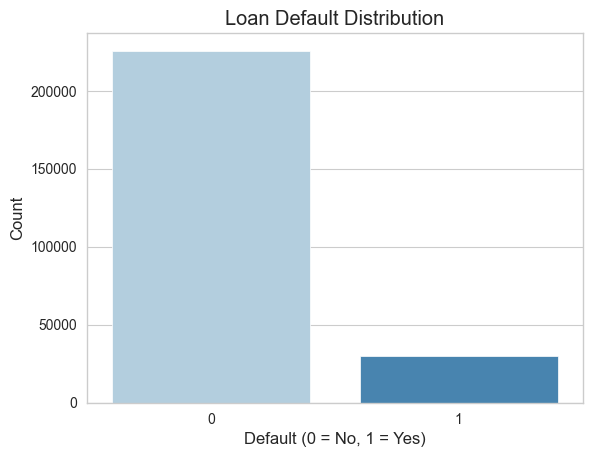

In [16]:
# 1. Default Distribution
plt.figure()
sns.countplot(x='Default',hue="Default",data=df,palette="Blues",legend=False)
plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

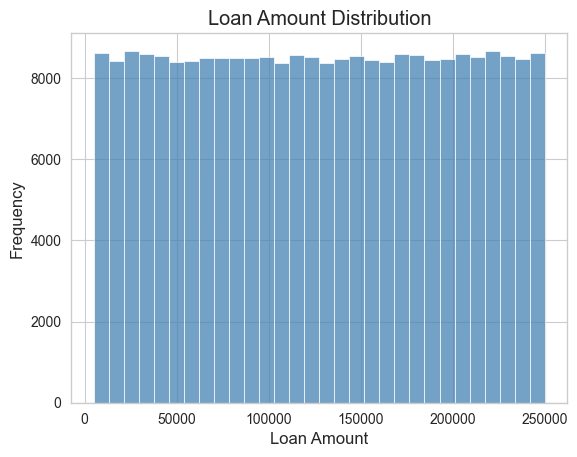

In [17]:
#2. Loan Amount Distribution
plt.figure()
sns.histplot(df['LoanAmount'], bins=30, color="steelblue")
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

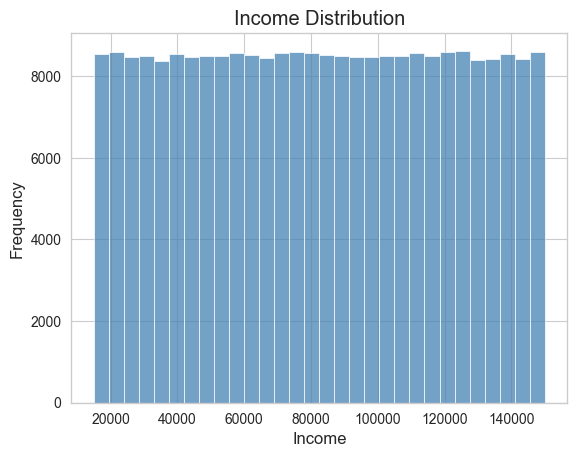

In [27]:
#3. Income Distribution

plt.figure()
sns.histplot(df['Income'], bins=30, color="steelblue")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

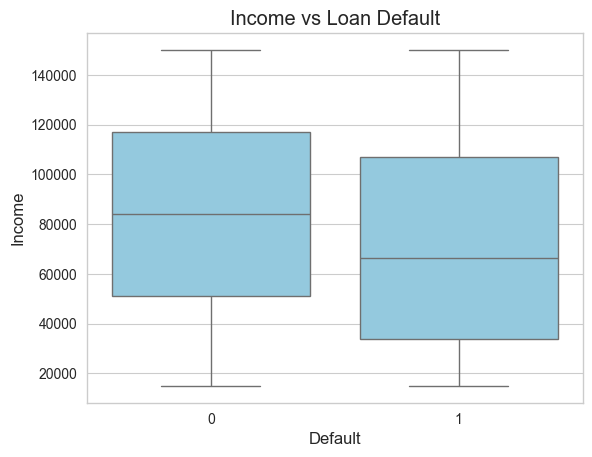

In [19]:
#4. Income vs Default

plt.figure()
sns.boxplot(x='Default', y='Income', data=df, color="skyblue")
plt.title("Income vs Loan Default")
plt.xlabel("Default")
plt.ylabel("Income")
plt.show()

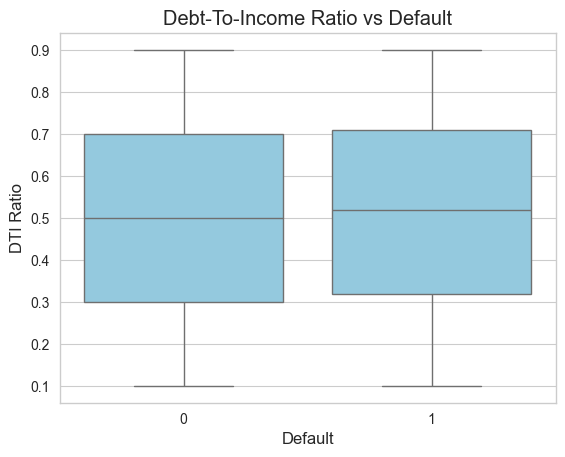

In [20]:
# 5. Debt-To-Income Ratio vs Default

plt.figure()
sns.boxplot(x='Default', y='DTIRatio', data=df, color="skyblue")
plt.title("Debt-To-Income Ratio vs Default")
plt.xlabel("Default")
plt.ylabel("DTI Ratio")
plt.show()

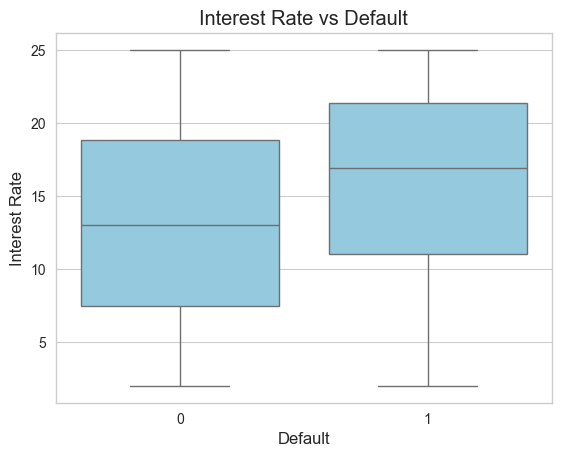

In [21]:
# 6. Interest Rate vs Default

plt.figure()
sns.boxplot(x='Default', y='InterestRate', data=df, color="skyblue")
plt.title("Interest Rate vs Default")
plt.xlabel("Default")
plt.ylabel("Interest Rate")
plt.show()

In [22]:
# 7. Feature Engineering

df['Income_to_Loan_Ratio'] = df['Income'] / df['LoanAmount']

print("\nNew Feature Created: Income_to_Loan_Ratio")


New Feature Created: Income_to_Loan_Ratio



Risk Level Distribution:
risk_level
Low Risk    255347
Name: count, dtype: int64


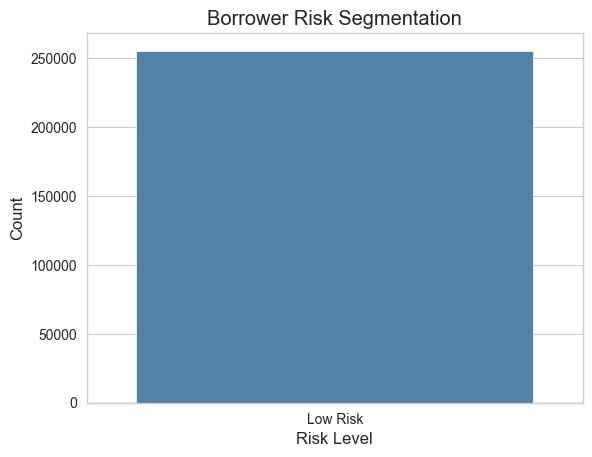

In [23]:
# 8. Risk Segmentation

df['risk_level'] = np.where(df['DTIRatio'] > 20, "High Risk", "Low Risk")

print("\nRisk Level Distribution:")
print(df['risk_level'].value_counts())

plt.figure()
sns.countplot(x='risk_level', data=df, color="steelblue")
plt.title("Borrower Risk Segmentation")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

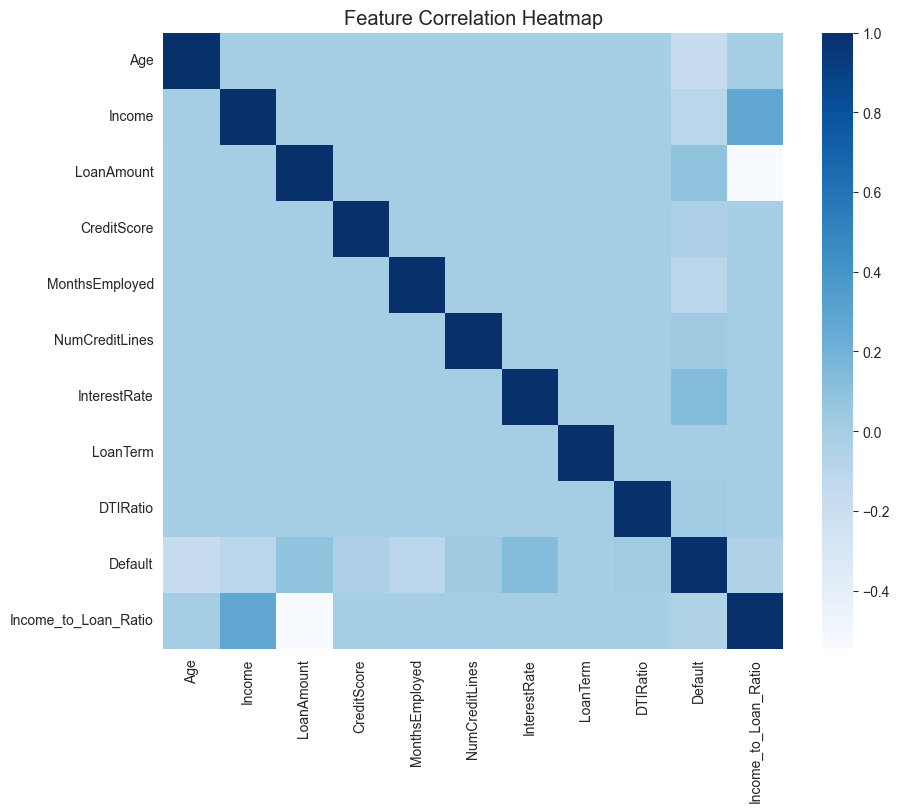

In [24]:
# 9. Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="Blues", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [25]:
# 12. Key Insights

print("\n========== KEY INSIGHTS ==========")

print("1. Loan default distribution shows imbalance between paid and default loans.")
print("2. Higher Debt-To-Income ratio is associated with higher default risk.")
print("3. Borrowers with lower income tend to have higher default probability.")
print("4. Higher interest rates are often associated with riskier borrowers.")
print("5. Income-to-loan ratio helps assess borrower repayment capacity.")


========== KEY INSIGHTS ==========
1. Loan default distribution shows imbalance between paid and default loans.
2. Higher Debt-To-Income ratio is associated with higher default risk.
3. Borrowers with lower income tend to have higher default probability.
4. Higher interest rates are often associated with riskier borrowers.
5. Income-to-loan ratio helps assess borrower repayment capacity.
